# Vibrational Properties of a 1D Lattice — from $H_{\text{ion}}$ to Phonons

We start from a crystal made of ions and valence electrons. Under the B.O. approximation the fast electrons follow the slow ions adiabatically, so their energy becomes part of a potential $V(R)$ that the ions move in. This lets us drop the electrons as explicit variables and study the **bare ionic lattice** alone.

Writing the ionic positions as displacements about equilibrium, $R_i = R_{i0} + u_i$, the potential is Taylor-expanded around the equilibrium configuration $\{R_{10},\dots,R_{n0}\}$. The constant term is an irrelevant energy offset; the linear term vanishes because the net force on every ion is zero at equilibrium; and the first surviving term is quadratic — the **harmonic approximation**:

$$H' = \underbrace{\frac{1}{2}\sum_i M_i\,\dot u_i^2}_{\text{kinetic}} \;+\; \underbrace{\frac{1}{2}\sum_{ij} u_i\,\Phi_{ij}\,u_j}_{\text{harmonic potential}}, \qquad \Phi_{ij} = \left.\frac{\partial^2 V}{\partial u_i \partial u_j}\right|_{0}.$$

Here we try to build that Hamiltonian firstly for a 1D chain, and then expand it toward the real Si crystaline. For 1D: first the lattice, then the harmonic potential $V(u)$, then the force-constant (Hessian) matrix $\Phi$, and finally the dynamical matrix whose eigenvalues are the phonon frequencies.

In [13]:
# Dependencies
import numpy as np  
import matplotlib.pyplot as plt

# VASP helpers


import getpass, subprocess, os, glob


## 1. The lattice

First we set up a simple 1D chain: $N$ atoms at equilibrium positions spaced by $a$, together with an array of displacements $u_i$ (all zero for the crystal at rest). The equilibrium positions serve only as fixed labels that fix *which atoms are neighbors*; all the physics lives in the displacements.

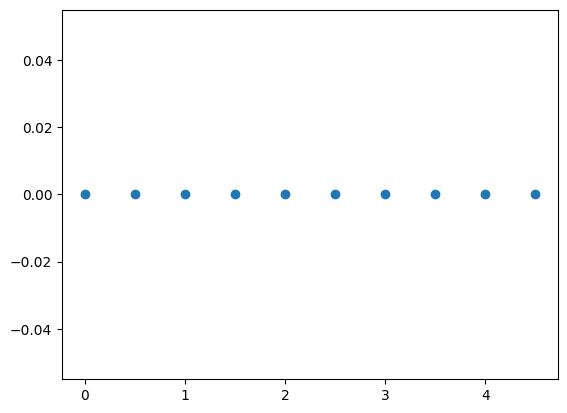

In [14]:
def lattice_generate(N, a):

    lat_points = [j*a for j in range(N)]
    lat_points = np.array(lat_points)
    displacements = np.zeros_like(lat_points)
    return lat_points, displacements

eq_positions, displacements = lattice_generate(10, 0.5)

# Let's place it on a 1-d plot 
plt.scatter(eq_positions, displacements)

## 2. Kinetic and potential energy (the coupling)

The two parts of $H'$:

$$\text{KE} = \frac{1}{2}M\sum_i \dot u_i^2 \qquad \text{PE} = \frac{1}{2}k\sum_i (u_i - u_{i+1})^2$$

- The kinetic energy is a sum over atoms — each atom carries its own velocity with no cross terms, so it is **diagonal**. 

- The potential energy couples *pairs* of neighboring atoms through their displacement **difference** $(u_i - u_{i+1})$, so it is **off-diagonal**. 

Depending on differences (not absolute positions) is forced by translational invariance: shifting every atom by the same amount leaves all differences unchanged, so a rigid translation of the whole crystal costs zero energy. The absolute equilibrium positions $R_{i0}$ appear nowhere in the energy — they only fix the neighbor connectivity.

Because of this asymmetry we must **diagonalize**: the potential mixes the atoms together, and finding the normal modes means finding the basis in which that coupling is undone.

In [15]:
N = 10
S = 0.5
K = 1

def potential(u, k, periodic = False):
    V = 0.0
    
    if periodic:
        # now we compute the V as pairwise points in lattice
        for i in range(N):
            V += 0.5 * k*(u[i]-u[(i+1)%N])**2 
    return V

lat, disp = lattice_generate(N, S)
disp = np.zeros(N)
disp[4] = 1
V = potential(disp, periodic=True, k = K)
print(V)

1.0


## 3. The force-constant matrix (Hessian)

We now differentiate the harmonic potential to get the force constants $\Phi_{ij} = \partial^2 V / \partial u_i \partial u_j$, evaluated at equilibrium.

$$V = \frac{1}{2}k\sum_i (u_i - u_{i+1})^2$$

**First derivative — the force.** A given $u_i$ appears in two bonds: the bond to its left, $(u_{i-1}-u_i)$, and the bond to its right, $(u_i-u_{i+1})$. Every other bond is a constant with respect to $u_i$ and drops out. Applying the chain rule to each surviving bond (the inside derivative is $+1$ for the right bond, $-1$ for the left):

$$\frac{\partial V}{\partial u_i} = k(u_i - u_{i+1}) + k(u_i - u_{i-1}) = k\,(2u_i - u_{i-1} - u_{i+1})$$

so the force is $F_i = -\partial V/\partial u_i = k(u_{i-1} + u_{i+1} - 2u_i)$ — the discrete chain force, with the $2u_i$ coming from $u_i$ sitting in two bonds (one spring on each side).

**Second derivative — the Hessian.** The force is linear in the displacements, so its derivatives are constant coefficients:

$$\Phi_{ij} = \frac{\partial^2 V}{\partial u_i \partial u_j} =
\begin{cases}
+2k & i = j \quad(\text{self / diagonal}) \\
-k & j = i \pm 1 \quad(\text{nearest neighbor}) \\
0 & \text{otherwise}
\end{cases}$$

In matrix form ($N=5$):

$$\Phi =
\begin{pmatrix}
2k & -k & 0 & 0 & 0 \\
-k & 2k & -k & 0 & 0 \\
0 & -k & 2k & -k & 0 \\
0 & 0 & -k & 2k & -k \\
0 & 0 & 0 & -k & 2k
\end{pmatrix}$$

For the **periodic** ring, atom $N{-}1$ also bonds back to atom $0$, adding $-k$ in the two far corners $\Phi_{0,N-1}$ and $\Phi_{N-1,0}$.

**Acoustic sum rule.** Every row sums to zero: $2k - k - k = 0$. This is not a coincidence — the two $-k$ neighbor terms come from the *same two bonds* that produced the $+2k$, so $\Phi_{ii} = -\sum_{j\neq i}\Phi_{ij}$. Physically it is the force-level statement of translational invariance: a rigid shift produces zero net force on every atom, which guarantees $\omega \to 0$ as $q \to 0$ for the acoustic branch.

In [16]:
def phi_analytic(k):
    phi = 2*k * np.eye(N)
    up_n = -k * np.diag(np.ones(N-1), 1)
    low_n = -k * np.diag(np.ones(N-1), -1)

    phi_an =    phi + up_n + low_n
    phi_an[0,-1] = -k
    phi_an[-1, 0] = -k  
    return phi_an

p = phi_analytic(K)

## 4. Verifying $\Phi$ numerically (finite differences)

Before trusting the hand-derived $2k/-k$ matrix, we verify it against the potential we built, by computing the Hessian numerically. This is the same method `phonopy` uses to extract force constants from DFT: treat $V$ as a black box and probe its curvature.

The mixed second derivative is the four-point finite-difference formula

$$\Phi_{ij} \approx \frac{V(u+\epsilon e_i+\epsilon e_j) - V(u+\epsilon e_i) - V(u+\epsilon e_j) + V(u)}{\epsilon^2},$$

where $e_i$ is a unit displacement of atom $i$ (i.e. `np.eye(N)[i]`) and $\epsilon$ is a small step. The "$+$ both $-$ only- $i$ $-$ only- $j$ $+$ base" combination isolates how the response to nudging $i$ *changes* when $j$ is also nudged — which is exactly what a mixed partial measures. If $i$ and $j$ are not coupled, the four terms cancel and $\Phi_{ij}=0$.

Since $V$ is harmonic, $\Phi$ is constant (independent of the displacement it is evaluated at), so we can probe at $u=0$. The `assert np.allclose(...)` confirms the numerical and analytic matrices agree — verifying simultaneously that $V$ is correct, that the hand derivative is correct, and that the periodic wrap bond is present in both.

In [17]:
def phi_num(k, u, eps=1e-5):

    phi = np.zeros((N,N))
    Vu = potential(u, k, periodic=True)
    for i in range(N): # for incorporating BC
        ei = eps*np.eye(N)[i]
        Vi = potential(u+ei, k, periodic=True)
        for j in range(N):
            ej = eps*np.eye(N)[j]
            Vj = potential(u+ej, k, periodic=True)
            Vboth = potential(u+ei+ej, k, periodic=True)
            phi[i,j] = (Vboth - Vi - Vj - Vu)/ eps**2

    return phi
phi_n = phi_num(K, displacements, 1e-5  )
print(p)

assert np.allclose(p, phi_n)

[[ 2. -1.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [-1.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]


## Why real-space is a dead end

So far everything is a real, massive object: $N$ ions with mass $M$, sitting at definite lattice points, held together by springs. There is no notion of a "wave" yet — we have literally built a system of **coupled harmonic oscillators**, and the force-constant matrix $\Phi$ is its complete description.

**The tractability problem.** Newton's second law for ion $i$ reads

$$M\ddot u_i = -\sum_j \Phi_{ij}\,u_j$$

This is a system of $N$ **coupled** second-order ODEs — coupled because $\Phi$ is off-diagonal, so each ion's motion depends on its neighbors'. For a real crystal $N \sim 10^{23}$, and the coupling means we cannot solve any single ion in isolation. Direct integration is hopeless. (Note also that each row of $\Phi$ sums to zero — the acoustic sum rule — which encodes translational invariance: shifting every ion equally produces no force.)

**The change of variables.** Instead of tracking $N$ individual trajectories, we track the *collective pattern*. Translational invariance guarantees that every unit cell is identical, so any normal motion can differ from cell to cell only by a **phase**. This licenses the plane-wave ansatz — the same amplitude in every cell, carried by a traveling phase:

$$u_l(t) = u_0\,e^{\,i(q R_l - \omega t)}$$

where $l$ labels the cell, $R_l = l\,a$ its equilibrium position, $q$ the wavevector, and $u_0$ the (cell-independent) amplitude.

**Substituting the ansatz.** The double time derivative brings down $-\omega^2$ ($\ddot u = -\omega^2 u$), and each coupled neighbor carries its own spatial phase. Dividing through by the reference cell's phase $e^{i(qR_l-\omega t)}$, the time factor $e^{-i\omega t}$ **cancels completely** — it is common to every term, since all ions in a mode share one frequency $\omega$ — while the *relative* phase between coupled cells survives:

$$\frac{e^{iqR_{l'}}}{e^{iqR_l}} = e^{\,iq(R_{l'}-R_l)} = e^{\,iqR_m}, \qquad R_m = R_{l'}-R_l.$$

That surviving phase is the entire origin of the $q$-dependence. The coupled ODE collapses to one algebraic equation per $q$:

$$M\,\omega^2\,u_0 = \sum_m \Phi(0,m)\,e^{\,iqR_m}\,u_0 \quad\Longrightarrow\quad D(q)\,u_0 = \omega^2 u_0,$$

with the **dynamical matrix** $D(q) = \tfrac{1}{M}\sum_m \Phi(0,m)\,e^{iqR_m}$. The intractable $N$-body real-space problem becomes one small $q$-space eigenvalue problem — a Fourier transform of the springs, solved wavevector by wavevector.

In [18]:
M = 1 # Mass assumed for ions
phi = p # The analytic one
a = S
def dyn_matrix(q):
    D = 0j # scalart imaginary number
    for m in (-1, 0, 1): # m is the coupling index (left, self, right)
        D += phi[0,m] * np.exp(1j * q * m * a) # Rm : the neighbor we are currently on=> m 
    return D/M
# Let's try the different q values
print(dyn_matrix(0))
print(dyn_matrix(np.pi/a).real)
print(dyn_matrix(0.7).imag)

0j
4.0
0.0


## Unit cell vs. crystal size — why $D(q)$ is $1\times1$ here

A point that reframes everything about the dynamical matrix: the labels **monatomic / diatomic**, and the *size* of $D(q)$, count **atoms per unit cell** — not the total number of atoms in the chain.

- **Total atoms** ($N=10$) is just the simulation size — how many times we tiled the pattern. With periodic boundaries it means "10 repeats of the motif."
- **Atoms per unit cell** is the size of the *repeating stamp* — the smallest tile that, stamped over and over, builds the whole chain.

Our chain is atom–atom–atom–…, all identical and equally spaced, so the smallest repeating tile holds **one** atom. That is what "**monatomic**" means: a one-atom basis, tiled 10 times. If instead the chain alternated heavy–light–heavy–light, the tile would hold **two** atoms — a **diatomic** chain — even if the total were still 10 or $10^{23}$.

**Why this sets the size of $D(q)$.** Translational symmetry makes every unit cell equivalent, so a normal mode can differ from cell to cell only by a phase $e^{iqR_l}$. That phase absorbs all the "which cell" information into the single continuous variable $q$. What remains is a matrix indexed only by the atoms *inside one cell*:

$$\text{size of } D(q) = (\text{atoms per unit cell}) \times (\text{spatial dimensions}).$$

So the huge real-space matrix $\Phi$ ($N\times N$) collapses, via the Fourier transform, into a small $q$-space matrix set only by the basis. For our 1D monatomic chain that is $1\times1$ per $q$ — a scalar. The 10 real-space atoms did not disappear; they were traded for the wavevector $q$. That trade is the whole reason lattice dynamics is tractable.

**Consequence — number of branches.** Diagonalizing $D(q)$ gives (atoms/cell)$\times$(dimensions) eigenvalues per $q$ — the phonon branches:

| system | atoms/cell | dim | $D(q)$ size | branches |
|---|---|---|---|---|
| our chain (monatomic) | 1 | 1 | $1\times1$ | 1 (acoustic) |
| diatomic chain | 2 | 1 | $2\times2$ | 2 (acoustic + optical) |
| silicon (3D) | 2 | 3 | $6\times6$ | 6 (3 acoustic + 3 optical) |

This is why our chain has a single acoustic branch and needed no `eigh` — a $1\times1$ matrix *is* its own eigenvalue, so $\omega^2(q)=D(q)$ directly. Going diatomic makes $D(q)$ a genuine $2\times2$ matrix whose diagonalization yields the second, optical branch.

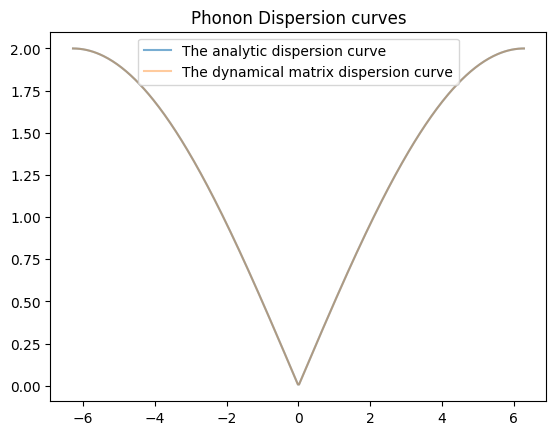

In [19]:
qs = np.linspace(-np.pi/a, np.pi/a, 400)
Ws = []
for q in qs:
    d = dyn_matrix(q)
    Ws.append(np.sqrt(d.real))
analytic_omega = 2*np.sqrt(K/M)*np.abs(np.sin(qs*a/2))


plt.plot(qs, analytic_omega, label = "The analytic dispersion curve", alpha = 0.6)
plt.plot(qs, Ws, label = "The dynamical matrix dispersion curve", linestyle = '-', alpha = 0.4)
plt.title("Phonon Dispersion curves")
plt.legend()

## Reading the dispersion curve

Each value of $q$ is a *frozen snapshot* of the chain displaced into a wave pattern; $q$ sets how many wiggles fit along the chain (wavelength $=2\pi/q$), i.e. the phase shift $qa$ between neighboring cells.

- **$q=0$:** infinite wavelength — every atom displaced identically (rigid translation). No spring is stretched, so no restoring force acts on this pattern and $\omega=0$. The force constants are unchanged; this pattern simply doesn't engage them. (This is the acoustic sum rule made visible.)
- **increasing $q$:** shorter wavelength — neighboring atoms move more out of step, springs stretch more, the restoring force stiffens, and $\omega$ rises.
- **$q=\pi/a$ (zone edge):** adjacent atoms fully opposed (up–down–up–down), the shortest pattern discrete atoms can hold, maximum stretch, maximum $\omega$.

The result is $\omega(q)=2\sqrt{K/M}\,|\sin(qa/2)|$: as $q$ sweeps the Brillouin zone $[-\pi/a,\pi/a]$, the argument $qa/2$ spans $[-\pi/2,\pi/2]$, so $\omega$ traces the $|\sin|$ hump from 0 at the center to its maximum at the edges. $q$ stops at $\pi/a$ because beyond it the patterns just repeat ones already counted — there is nothing between discrete atoms to carry a shorter wave.

Note: the first Brillouin zone is $q\in[-\pi/a,\ \pi/a]$; it is the *argument* $qa/2$ that spans $[-\pi/2,\pi/2]$.

## Animating the motion

We now have all the ingredients to display the actual atomic motion. The full solution is

$$u_l(t) = \mathrm{Re}\big[\,u_0\,e^{\,i(qR_l - \omega t)}\,\big],$$

and the physical displacement is the *real part* of the complex ansatz (atoms sit at real positions).

Notice the time component is **back**. The earlier derivation cancelled the $e^{-i\omega t}$ factor because it was common to every atom — but that did not delete time, it *factored it out* and stored it in $\omega$. Solving the time-independent eigenvalue problem gave us the two static ingredients (the polarization $u_0$ and the frequency $\omega$); to animate, we simply reattach the $e^{-i\omega t}$ we divided out and sweep $t$. The frequency that came from the *static* problem is exactly the rate at which the motion now oscillates.

We pick a single $q$ (one mode), evaluate its $\omega=\sqrt{D(q)}$, and step $t$ forward — plotting each atom at `eq_positions + displacement(t)`. The strobe stacks several time snapshots so the traveling wave is visible at a glance; the live animation plays it continuously.

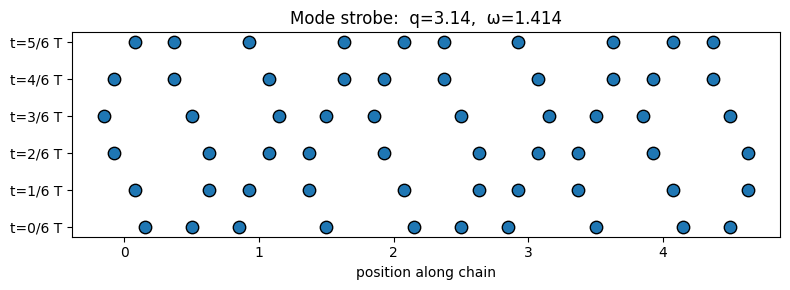

In [20]:
# claude generated cell
A     = 0.15                 # visual amplitude (exaggerated so motion is visible)
q     = np.pi/(2*a)          # one chosen mode
omega = np.sqrt(dyn_matrix(q).real)

def displacement(t):
    # complex ansatz; physical displacement is its real part
    return (A * np.exp(1j*(q*eq_positions - omega*t))).real

# ---------- STROBE: time snapshots stacked vertically ----------
nframes = 6
T = 2*np.pi/omega                     # one full period
fig, ax = plt.subplots(figsize=(8, 3))
for f in range(nframes):
    t  = f*T/nframes
    ut = displacement(t)
    ax.scatter(eq_positions + ut, f*np.ones(N), s=80, c='C0', edgecolor='k', zorder=3)
ax.set_yticks(range(nframes))
ax.set_yticklabels([f"t={f}/{nframes} T" for f in range(nframes)])
ax.set_xlabel("position along chain")
ax.set_title(f"Mode strobe:  q={q:.2f},  ω={omega:.3f}")
plt.tight_layout(); plt.show()

# ---------- LIVE ANIMATION ----------
from matplotlib import animation
from IPython.display import HTML

fig2, ax2 = plt.subplots(figsize=(8, 1.8))
ax2.set_xlim(eq_positions.min()-a, eq_positions.max()+a)
ax2.set_ylim(-1, 1); ax2.set_yticks([])
scat = ax2.scatter(eq_positions, np.zeros(N), s=100, c='C0', edgecolor='k', zorder=3)

def update(frame):
    t  = frame * (T/40)
    ut = displacement(t)
    scat.set_offsets(np.c_[eq_positions + ut, np.zeros(N)])
    return scat,

anim = animation.FuncAnimation(fig2, update, frames=40, interval=50, blit=True)
plt.close(fig2)
HTML(anim.to_jshtml())     # renders inline, no ffmpeg needed

## Part II — A real 3D crystal: the phonon dispersion of silicon from first principles

We have already built the whole machinery on a 1D chain: harmonic potential → force constants $\Phi$ → dynamical matrix $D(q)$ → diagonalize → dispersion $\omega(q)$. **Nothing about that logic changes for real silicon.** What changes is only the *size* and *origin* of the ingredients:

| 1D toy (Part I) | 3D silicon (Part II) |
|---|---|
| $\Phi$ chosen by hand (spring constant $k$) | $\Phi$ computed from DFT (no fitting) |
| $\Phi$: scalar per bond | $\Phi$: $3\times3$ tensor per atom pair (oriented springs) |
| $q$: scalar in $[-\pi/a,\pi/a]$ | $q$: vector, walked along a path through the 3D Brillouin zone |
| $D(q)$: $1\times1$ | $D(q)$: $6\times6$ (2 atoms/cell × 3 directions) |
| 1 branch | 6 branches (3 acoustic + 3 optical) |

**The one genuinely new problem** is where $\Phi$ comes from. In Part I we *chose* the spring constant. For real silicon nobody knows it a priori — it is set by the electrons (the curvature of the Born–Oppenheimer potential $V(R)$). So we compute it from DFT, and the spring intuition survives completely: $\Phi$ is still "how stiff is the bond between these two atoms," just now measured by DFT instead of assumed.

**The main goal of this section:** obtain silicon's phonon dispersion $\omega(q)$ along the standard high-symmetry path, entirely from first principles — no fitted parameters — and check it against the known result (Yu–Cardona Fig. 3.1).

### The procedure in plain language

Real DFT phonons follow a five-step recipe. The whole thing is the 1D pipeline scaled up, with DFT supplying the force constants:

1. **Relax** the primitive Si cell so forces vanish (equilibrium — the point we Taylor-expand around).
2. **Build displaced supercells** — nudge one atom at a time (the DFT version of $\epsilon e_i$).
3. **Compute forces** on each displaced supercell with a single static VASP run. Force response → force constants $\Phi$.
4. **Assemble $\Phi$**, enforce the acoustic sum rule, and **interpolate + diagonalize** $D(q)$ along the $q$-path.
5. **Plot and check** $\omega(q)$ against the known silicon result.

Steps 1 and 3 are VASP (DFT); steps 2 and 4 are **phonopy**, the standard tool that handles the supercell bookkeeping and the Fourier interpolation. The cells below drive this on the remote cluster over SSH.

**What is phonopy?** Phonopy is a post-processing package that sits *around* a DFT code. It does the parts that are pure lattice-dynamics bookkeeping — generating the symmetry-inequivalent displacements, collecting the forces DFT returns, building and symmetrizing $\Phi$, then Fourier-transforming it to $D(q)$ and diagonalizing along any chosen path. It never does electronic structure itself; VASP provides the forces, phonopy provides the phonon machinery. In effect, phonopy is the production-grade version of the `phi_num` + `dyn_matrix` + eigensolve cells we wrote by hand in Part I.

In [21]:
PASS = getpass.getpass("Cluster password: ")
USER, HOST = "ws2505", "stud2.mpi.univie.ac.at"
REMOTE = "Ysafi_runs/disp_curve"

def run(cmd):
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    print(r.stdout)
    if r.returncode != 0: print("STDERR:", r.stderr)
    return r

SSH = f"sshpass -p '{PASS}' ssh -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null {USER}@{HOST}"
SCP = f"sshpass -p '{PASS}' scp -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null"

### Input files — what each one is and why

The calculation needs several VASP inputs, in two roles:

**Step 1 — relaxation** (`INCAR_RELAX`): phonons must be computed at the *relaxed* equilibrium geometry, where the net force on every atom is zero. If the cell is not relaxed, the linear (force) term of the energy expansion does not vanish and we get spurious imaginary frequencies near $\Gamma$. `IBRION=2, ISIF=3, NSW=50` relaxes both ions and cell shape; tight `EDIFF=1E-8` because force constants are *second* derivatives and extremely sensitive to SCF noise. `ISYM=2` keeps full symmetry on — unlike the strain sweeps (where we set `ISYM=0` because strain *broke* the cubic symmetry), the unstrained phonon cell has full symmetry and we want VASP to exploit it.

**Step 3 — static forces** (`INCAR_FORCE`): run on each displaced supercell. `IBRION=-1, NSW=1` means "compute forces once, move nothing" — we want the forces *at* the displaced configuration, not a relaxation. Same tight `EDIFF`.

**POSCAR**: the 2-atom diamond primitive cell of Si (lattice constant 5.43 Å, FCC vectors with the two-atom basis). This is the object whose $\Phi$ we are after.

**KPOINTS (two kinds):**
- `KPOINTS.prim` / `KPOINTS.sc` — regular Monkhorst–Pack grids for the *electronic* SCF sampling. The supercell grid is coarser (the cell is larger, so its Brillouin zone is smaller).
- These sample the **electronic** Brillouin zone. They are *not* the phonon path — a common confusion. The phonon $q$-path lives separately, in phonopy's `band.conf` (Step 4).

In [22]:
d = './PhononVasp'
POT_DIR = '../VASP/Equilibirium_run/outputs'
RESET_DIR = True

# STEP 1: relax the primitive cell
INCAR_RELAX = """ISTART=0
ICHARG=2
ENCUT=320
ISMEAR=0
SIGMA=0.05
ISYM=2
EDIFF=1E-8
EDIFFG=-1E-4
NSW=50
IBRION=2
ISIF=3
GGA=PE
LREAL=.FALSE.
"""

# STEP 3: STATIC FORCES on displaced supercell (finite-displacement route)
# IBRION=-1 = compute forces only, no ion movement, no DFPT
INCAR_FORCE = """ISTART=0
ICHARG=2
ENCUT=320
ISMEAR=0
SIGMA=0.05
ISYM=2
EDIFF=1E-8
IBRION=-1
NSW=1
GGA=PE
LREAL=.FALSE.
"""

POSCAR = """Si diamond
5.43
 0.0 0.5 0.5
 0.5 0.0 0.5
 0.5 0.5 0.0
Si
 2
Direct
0.00 0.00 0.00
0.25 0.25 0.25
"""

KPOINTS_PRIM = "auto\n0\nGamma\n8 8 8\n0 0 0\n"    # primitive cell (relax)
KPOINTS_SC   = "auto\n0\nGamma\n4 4 4\n0 0 0\n"    # 2x2x2 supercell (forces)

# phonopy band path: Gamma-X-K-Gamma-L
BAND_CONF = """ATOM_NAME = Si
DIM = 2 2 2
BAND = 0.0 0.0 0.0  0.5 0.0 0.5  0.375 0.375 0.75  0.0 0.0 0.0  0.5 0.5 0.5
BAND_LABELS = \\Gamma X K \\Gamma L
BAND_POINTS = 101
"""

if RESET_DIR:
    for f in glob.glob(f'{d}/*'):
        os.remove(f)

os.makedirs(d, exist_ok=True)
open(f'{d}/INCAR.relax','w').write(INCAR_RELAX)
open(f'{d}/INCAR.force','w').write(INCAR_FORCE)
open(f'{d}/POSCAR','w').write(POSCAR)
open(f'{d}/KPOINTS.prim','w').write(KPOINTS_PRIM)
open(f'{d}/KPOINTS.sc','w').write(KPOINTS_SC)
open(f'{d}/band.conf','w').write(BAND_CONF)
os.system(f'cp {POT_DIR}/POTCAR {d}/')

run(f"{SSH} 'mkdir -p {REMOTE}'")
run(f"{SCP} {d}/* {USER}@{HOST}:{REMOTE}/")
print("inputs uploaded")



inputs uploaded


### Running the pipeline

The remaining cells drive the five steps on the cluster, each writing a small shell script, copying it over, and running it. **Step 1 — relaxation:** the script below copies the relaxation INCAR and primitive KPOINTS, runs VASP, saves the relaxed geometry as `POSCAR-relaxed`, and confirms convergence. Everything downstream is built on this relaxed cell — if forces here are not driven to zero, the phonon frequencies near $\Gamma$ will be spurious.

In [23]:
step1 = """source /etc/profile.d/modules.sh 2>/dev/null || true
module load intel-oneapi-mkl
cp INCAR.relax INCAR
cp KPOINTS.prim KPOINTS
vasp > log.relax 2>&1
cp CONTCAR POSCAR-relaxed
echo "=== converged? ==="
grep "reached required accuracy" OUTCAR && echo OK || echo "NOT converged"
grep -A1 "length of vectors" OUTCAR | tail -2
"""
open(f'{d}/s1.sh',"w").write(step1)
run(f"{SCP} {d}/s1.sh {USER}@{HOST}:{REMOTE}/")
run(f"{SSH} 'cd {REMOTE} && bash --login s1.sh'")


=== converged? ===
 reached required accuracy - stopping structural energy minimisation
OK
  length of vectors
     3.865714583  3.865714583  3.865714583     0.316822374  0.316822374  0.316822374



CompletedProcess(args="sshpass -p 'vasp26' ssh -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null ws2505@stud2.mpi.univie.ac.at 'cd Ysafi_runs/disp_curve && bash --login s1.sh'", returncode=0, stdout='=== converged? ===\n reached required accuracy - stopping structural energy minimisation\nOK\n  length of vectors\n     3.865714583  3.865714583  3.865714583     0.316822374  0.316822374  0.316822374\n', stderr="Warning: Permanently added 'stud2.mpi.univie.ac.at' (ED25519) to the list of known hosts.\n/home/ws2505/.bash_profile: line 1: .bashrc: No such file or directory\n")

### Step 3 — build the displaced supercell and compute forces (finite-displacement method)

This is the heart of the calculation, and it is *literally* the finite-difference Hessian from Part I, run by DFT instead of by our `potential` function.

**Why a supercell?** Force constants couple an atom to its neighbors out to some range. A single primitive cell (2 atoms) only reaches nearest images and gives $\Phi$ at $q=0$ only. Tiling into a $2\times2\times2$ supercell (16 atoms) lets $\Phi$ reach far enough neighbors that phonopy can later interpolate $\omega(q)$ at *any* $q$. The supercell size sets how far the "springs" extend.

**The finite-displacement idea.** `phonopy -d --dim="2 2 2"` generates a small set of supercells, each with **one atom nudged** by a tiny displacement — the DFT version of the unit nudge $\epsilon e_i$ we used in `phi_num`. For each displaced supercell we run a **single static VASP calculation** (`IBRION=-1`, `NSW=1`: compute forces on all atoms, move nothing) and record the resulting forces. The force on atom $j$ caused by displacing atom $i$ *is* the force constant $\Phi_{ij}$ — the numerical derivative $\Phi_{ij} = -\partial F_j / \partial u_i$. Symmetry reduces the number of displacements needed (for diamond Si, only a couple).

This is why we do **not** need `IBRION=8` (DFPT linear response) here: the finite-displacement method gets the same $\Phi$ by explicitly nudging atoms and reading forces — the exact operational picture we built in Part I, now with DFT as the black-box energy.

In [24]:
step2 = """source /etc/profile.d/modules.sh 2>/dev/null || true
module load intel-oneapi-mkl
export PATH=$HOME/.local/bin:$PATH

echo "=== phonopy version ==="
phonopy --version

echo "=== making displaced supercell ==="
phonopy -d --dim="2 2 2" -c POSCAR-relaxed

NDISP=$(ls POSCAR-0* 2>/dev/null | wc -l)
echo "=== displacements found: $NDISP ==="
[ "$NDISP" -eq 0 ] && { echo "still zero, stopping"; exit 1; }
ls POSCAR-0*

echo "=== forces ==="
for f in POSCAR-0*; do
    n=${f#POSCAR-}
    cp "$f" POSCAR; cp INCAR.force INCAR; cp KPOINTS.sc KPOINTS
    vasp > log.force-$n 2>&1
    cp vasprun.xml vasprun-$n.xml
    echo "  done: $n"
done

echo "=== FORCE_SETS ==="
phonopy -f vasprun-*.xml
ls -l FORCE_SETS && echo SUCCESS || echo FAILED
"""
open(f'{d}/s2.sh',"w").write(step2)
run(f"{SCP} {d}/s2.sh {USER}@{HOST}:{REMOTE}/")
run(f"{SSH} 'cd {REMOTE} && bash --login s2.sh'")


=== phonopy version ===
=== making displaced supercell ===
        _
  _ __ | |__   ___  _ __   ___   _ __  _   _
 | '_ \| '_ \ / _ \| '_ \ / _ \ | '_ \| | | |
 | |_) | | | | (_) | | | | (_) || |_) | |_| |
 | .__/|_| |_|\___/|_| |_|\___(_) .__/ \__, |
 |_|                            |_|    |___/
                                       3.5.1

-------------------------[time 2026-08-07 12:25:22]-------------------------
Compiled with OpenMP support (max 1 threads).
Python version 3.10.12
Spglib version 2.7.0

Crystal structure was read from "POSCAR-relaxed".
Unit of length: angstrom
Displacements creation mode
  Systematic displacements
Settings:
  Supercell: [2 2 2]
Spacegroup: Fd-3m (227)
Number of symmetry operations in supercell: 384
Use -v option to watch primitive cell, unit cell, and supercell structures.

Generated number of supercells: 1
"phonopy_disp.yaml" and supercells have been created.

Summary of calculation was written in "phonopy_disp.yaml".
-------------------------[time

CompletedProcess(args="sshpass -p 'vasp26' ssh -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null ws2505@stud2.mpi.univie.ac.at 'cd Ysafi_runs/disp_curve && bash --login s2.sh'", returncode=0, stdout='=== phonopy version ===\n=== making displaced supercell ===\n        _\n  _ __ | |__   ___  _ __   ___   _ __  _   _\n | \'_ \\| \'_ \\ / _ \\| \'_ \\ / _ \\ | \'_ \\| | | |\n | |_) | | | | (_) | | | | (_) || |_) | |_| |\n | .__/|_| |_|\\___/|_| |_|\\___(_) .__/ \\__, |\n |_|                            |_|    |___/\n                                       3.5.1\n\n-------------------------[time 2026-08-07 12:25:22]-------------------------\nCompiled with OpenMP support (max 1 threads).\nPython version 3.10.12\nSpglib version 2.7.0\n\nCrystal structure was read from "POSCAR-relaxed".\nUnit of length: angstrom\nDisplacements creation mode\n  Systematic displacements\nSettings:\n  Supercell: [2 2 2]\nSpacegroup: Fd-3m (227)\nNumber of symmetry operations in supercell: 384\nUse -v opt

### Step 3b — assemble force constants and extract the dispersion

`phonopy --fc-symmetry` reads the forces from all displaced runs (`vasprun.xml` files), assembles the full force-constant matrix $\Phi$, and — critically — **enforces the acoustic sum rule** (`--fc-symmetry` symmetrizes $\Phi$ so that $\sum_j \Phi_{ij}=0$). This is the 3D analogue of the row-sum-zero property we verified by hand in Part I; without it the acoustic branches would not go to zero at $\Gamma$. `phonopy-bandplot` then writes the dispersion to a plottable table, and we count any negative (imaginary) frequencies as a stability check.

In [25]:
step3 = """export PATH=$HOME/.local/bin:$PATH
phonopy --fc-symmetry band.conf
phonopy-bandplot --gnuplot band.yaml > band.dat
echo "=== outputs: ==="
ls -l band.yaml band.dat
echo "=== imaginary (THz)? ==="
awk 'NF==2 && $2<-0.05{c++} END{print "negatives:",c+0}' band.dat
"""
open(f'{d}/s3.sh',"w").write(step3)
run(f"{SCP} {d}/s3.sh {USER}@{HOST}:{REMOTE}/")
run(f"{SSH} 'cd {REMOTE} && bash --login s3.sh'")

run(f"{SCP} {USER}@{HOST}:{REMOTE}/band.yaml {d}/")
run(f"{SCP} {USER}@{HOST}:{REMOTE}/band.dat {d}/")
print("fetched")


        _
  _ __ | |__   ___  _ __   ___   _ __  _   _
 | '_ \| '_ \ / _ \| '_ \ / _ \ | '_ \| | | |
 | |_) | | | | (_) | | | | (_) || |_) | |_| |
 | .__/|_| |_|\___/|_| |_|\___(_) .__/ \__, |
 |_|                            |_|    |___/
                                       3.5.1

-------------------------[time 2026-08-07 12:28:00]-------------------------
Compiled with OpenMP support (max 1 threads).
Python version 3.10.12
Spglib version 2.7.0

"band.conf" was read as phonopy configuration file.
Crystal structure was read from "POSCAR".
Unit of length: angstrom
Band structure mode
Settings:
  Force constants symmetrization: on
  Supercell: [2 2 2]
Spacegroup: Cm (8)
Number of symmetry operations in supercell: 16
Use -v option to watch primitive cell, unit cell, and supercell structures.

=== outputs: ===
-rw-r--r-- 1 ws2505 extern  45120 Aug  7 12:28 band.dat
-rw-r--r-- 1 ws2505 extern 132941 Aug  5 13:22 band.yaml
=== imaginary (THz)? ===
negatives: 0



fetched


### Step 4 — the $q$-path, and interpolating $D(q)$ along it

**Why this particular path.** In 1D the Brillouin zone was the interval $[-\pi/a,\pi/a]$ — a single line to sweep. In 3D it is a polyhedron, which cannot be drawn on a flat axis, so we walk a **path through its high-symmetry points** and plot $\omega$ vs. distance along that path. The standard FCC path is

$$\Gamma \to X \to K \to \Gamma \to L,$$

with (in reciprocal/fractional coordinates): **$\Gamma=(0,0,0)$** the zone center where all acoustic branches vanish; **$X=(0,\tfrac12,\tfrac12)$** the $\langle100\rangle$ boundary (the $0.5$ = halfway to the boundary in reciprocal space; the direction of Si's $\Delta$-valleys); and **$L=(\tfrac12,\tfrac12,\tfrac12)$** the $\langle111\rangle$ boundary (Ge's valley direction, and where trigonal-shear physics lives). Each segment is one straight $q$-sweep — a 3D copy of the single 1D sweep from Part I, stitched end to end. High-symmetry points are chosen because branch extrema and degeneracies sit there.

*(The `X_par`/`X_perp` labels from the strain-sweep KPOINTS have no meaning here — parallel/perpendicular only made sense relative to an imposed strain axis. For the unstrained cell all X-points are equivalent by cubic symmetry.)*

**What this step does.** With $\Phi$ known, phonopy Fourier-interpolates it to every $q$ on the path, builds $D(q)$, and diagonalizes — the $6\times6$ version of exactly what `dyn_matrix` did in Part I. The path is specified in `band.conf`; output is `band.yaml`.

*Workflow note:* the force loop leaves a *displaced* structure as `POSCAR`, so this step restores the relaxed primitive cell (`POSCAR-relaxed`) first — the band path must reference the true equilibrium geometry.

In [26]:
band = """
export PATH=$HOME/.local/bin:$PATH

# restore the correct undisplaced cell as POSCAR (the loop left a displaced one)
cp POSCAR-relaxed POSCAR

echo "=== running band step on the RELAXED cell ==="
phonopy --fc-symmetry -c POSCAR-relaxed band.conf 2>&1 | tail -25

echo "=== band.yaml created? ==="
ls -l band.yaml 2>/dev/null || echo "STILL MISSING"
"""

open(f'{d}/band.sh',"w").write(band)
run(f"{SCP} {d}/band.sh {USER}@{HOST}:{REMOTE}/")
run(f"{SSH} 'cd {REMOTE} && bash --login band.sh'")


=== running band step on the RELAXED cell ===

Displacement-force dataset was read from "FORCE_SETS".
Max drift of force constants: 0.00000000 (xx) 0.00000000 (yy) 
Max drift after traditional symmetrization: 0.00000000 (xx) 0.00000000 (xx) 

****************************************************************************
 The "phonopy" command for running phonon calculations will be phased out in 
 the future. It is recommended to use the "phonopy-load" command instead.
 For more details, please refer to this link.
 https://phonopy.github.io/phonopy/phonopy-load.html
****************************************************************************
Reciprocal space paths in reduced coordinates:
[ 0.000  0.000  0.000] --> [ 0.500  0.000  0.500]
[ 0.500  0.000  0.500] --> [ 0.375  0.375  0.750]
[ 0.375  0.375  0.750] --> [ 0.000  0.000  0.000]
[ 0.000  0.000  0.000] --> [ 0.500  0.500  0.500]

Summary of calculation was written in "phonopy.yaml".
-------------------------[time 2026-08-07 12:28:0

CompletedProcess(args="sshpass -p 'vasp26' ssh -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null ws2505@stud2.mpi.univie.ac.at 'cd Ysafi_runs/disp_curve && bash --login band.sh'", returncode=0, stdout='=== running band step on the RELAXED cell ===\n\nDisplacement-force dataset was read from "FORCE_SETS".\nMax drift of force constants: 0.00000000 (xx) 0.00000000 (yy) \nMax drift after traditional symmetrization: 0.00000000 (xx) 0.00000000 (xx) \n\n****************************************************************************\n The "phonopy" command for running phonon calculations will be phased out in \n the future. It is recommended to use the "phonopy-load" command instead.\n For more details, please refer to this link.\n https://phonopy.github.io/phonopy/phonopy-load.html\n****************************************************************************\nReciprocal space paths in reduced coordinates:\n[ 0.000  0.000  0.000] --> [ 0.500  0.000  0.500]\n[ 0.500  0.000  0.500] --> [ 

### Reading `band.yaml` and plotting

`band.yaml` is phonopy's output: for every $q$-point along the path it stores the cumulative `distance` along the path (the x-axis of the plot) and the list of `frequency` values (the 6 branches). We load it and plot frequency vs. path-distance — exactly the format of the Yu–Cardona figure.

**The sanity checks that tell you the calculation is sound** (look for these in the plot):

1. **Acoustic branches → 0 at $\Gamma$.** The three acoustic branches must reach exactly zero frequency at $\Gamma$. This is the acoustic sum rule — the same $\omega\to0$ at $q=0$ we saw in the 1D chain, now in 3D. A finite gap or a dip below zero at $\Gamma$ signals an unrelaxed cell or a sum-rule violation in $\Phi$.
2. **No imaginary frequencies.** Plotted as negative values. Silicon is dynamically stable, so *any* negative branch is a numerical artifact (unrelaxed structure, loose `EDIFF`, or too-small supercell). The check at the end of the previous cell counts these.
3. **Six branches**, with the two transverse pairs degenerate along $\Gamma\to X$ (so you see ~4 distinct lines there — symmetry hiding two).
4. **Top optical frequency $\approx 15.5$ THz** at $\Gamma$, triply degenerate — this is the $\Gamma_{25'}$ mode, the *same symmetry label as the trigonal-shear strain channel* that governs $\pi_{44}$. The phonon plot literally shows where that physics lives.

q-points: 404  branches: 6
freq range (THz): -0.0 to 15.09


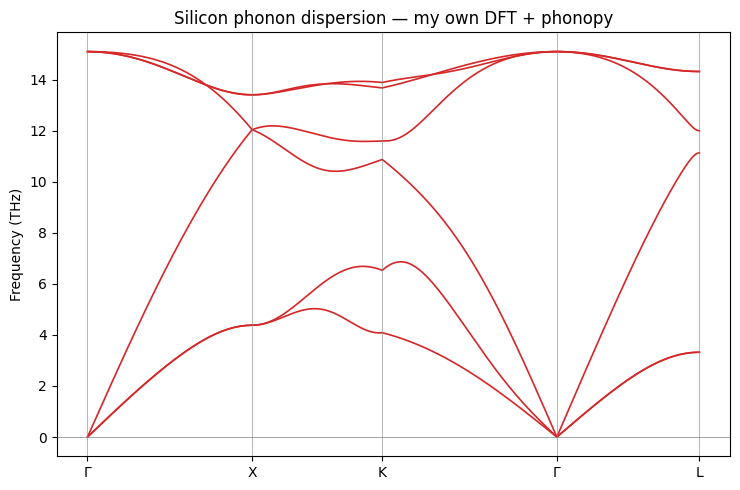

In [27]:
import yaml, numpy as np, matplotlib.pyplot as plt

with open("./PhononVasp/band.yaml") as f:
    bs = yaml.safe_load(f)

dist  = np.array([p["distance"] for p in bs["phonon"]])
freqs = np.array([[b["frequency"] for b in p["band"]] for p in bs["phonon"]])
print("q-points:", freqs.shape[0], " branches:", freqs.shape[1])
print("freq range (THz):", round(float(freqs.min()),2), "to", round(float(freqs.max()),2))

# high-symmetry tick locations: where the path segments meet
# phonopy stores segment breaks; find them from distance resets or label points
labels = ["Γ", "X", "K", "Γ", "L"]
seg_ends = [dist[0]]
for i in range(1, len(dist)):
    if dist[i] == dist[i-1]:      # segment boundary (distance repeats)
        seg_ends.append(dist[i])
seg_ends.append(dist[-1])
# fallback if boundaries not detected cleanly:
if len(seg_ends) != len(labels):
    seg_ends = np.linspace(dist.min(), dist.max(), len(labels))

plt.figure(figsize=(7.5,5))
for b in range(freqs.shape[1]):
    plt.plot(dist, freqs[:,b], 'C3-', lw=1.2)
plt.axhline(0, color='gray', lw=0.5)
for x in seg_ends:
    plt.axvline(x, color='gray', lw=0.4)
plt.xticks(seg_ends, labels)
plt.ylabel("Frequency (THz)")
plt.title("Silicon phonon dispersion — my own DFT + phonopy")
plt.tight_layout()
plt.show()



# Analysis of the Silicon Phonon Dispersion

The phonon dispersion describes how vibrational frequencies vary with wavevector **q** across the Brillouin zone. Computed here for silicon via DFT + **phonopy** along the path Γ → X → K → Γ → L, it already reveals the crystal's dynamic stability, vibrational spectrum, sound velocities, and — indirectly — its role in electronic transport.

## What the dispersion tells us

**Dynamic stability.** All frequencies are positive throughout the zone. Imaginary frequencies (plotted as negative) would mean the crystal spontaneously distorts into another structure; their absence confirms the optimized diamond-cubic silicon is dynamically stable.

**Six branches.** With two atoms in the primitive cell, there are 3N = 6 branches: three acoustic and three optical — matching lattice-dynamics theory.

## Lattice displacements

The physical motion is the displacement of atoms from equilibrium: atom i at **R**_i moves to **R**_i + **u**_i(t). These displacements propagate as collective waves — each atom coupled to its neighbors through the bonds — not as independent motions. A normal mode has the form

$$\mathbf{u}(\mathbf{r},t) = \mathbf{A}\,e^{i(\mathbf{q}\cdot\mathbf{r} - \omega t)},$$

where **q** sets the wavelength, ω the frequency, and **A** the polarization vector (the direction of atomic motion). The dispersion describes how these collective vibrations evolve as their wavelength changes.

## Acoustic vs optical branches

**Acoustic** (lower three): begin at ω = 0 at Γ, neighboring atoms nearly in phase. Near Γ the dispersion is linear, ω ≈ v_s q, with the sound velocity v_s = (dω/dq)|_{q→0} — the acoustic slope at the zone center. Long-wavelength acoustic phonons *are* sound waves.

**Optical** (upper three): neighboring atoms move out of phase, with finite frequency even at Γ — near 15 THz for silicon, agreeing with experiment and prior DFT. Optical branches are flatter (lower group velocity v_g = dω/dq), so they carry far less heat than acoustic phonons.

## Quantization → phonons

Classically the lattice could hold any energy; quantum mechanically the vibrations come in discrete quanta — phonons — each of energy

$$E = h\nu = \hbar\omega.$$

For silicon's highest optical phonons (ν ≈ 15 THz), E = hν ≈ **62 meV**. Electrons therefore exchange vibrational energy with the lattice only in discrete packets of ~62 meV, not continuously — an electron scattering off such a phonon gains or loses exactly this quantum.

## Why phonons matter for mobility

A perfect crystal at T = 0 has no vibrations; electrons see a perfectly periodic potential and scatter minimally. At finite T, atomic vibrations perturb the local potential, creating time-dependent disturbances that scatter electrons. Mobility is

$$\mu = \frac{e\tau}{m^*},$$

and phonons act on the **relaxation time** τ: more electron–phonon scattering shortens τ and lowers μ. The dispersion doesn't determine μ directly, but it governs the dominant scattering mechanism limiting transport.

## The missing link: electron–phonon coupling

Connecting vibrations to transport requires the electron–phonon coupling matrix element

$$g_{mn\nu}(\mathbf{k},\mathbf{q}),$$

the amplitude for an electron in state **k** (band n) to scatter to **k+q** (band m) by absorbing or emitting phonon (q, ν). It is the derivative of the electronic potential with respect to the phonon displacement, projected between Bloch states. Strong coupling → more scattering, shorter τ, lower μ. This coupling is the essential bridge between phonon calculations and electronic transport.

## What the dispersion *cannot* give

From phonons alone one cannot obtain mobility, conductivity, scattering rates, carrier lifetimes, effective masses, or the electronic band structure. The dispersion specifies only which vibrations exist, their frequencies, and how they propagate. Transport requires combining electronic structure with phonons through the coupling g.

## The complete workflow

```mermaid
flowchart TD
A[Crystal Structure]
A --> B[DFT Electronic Structure]
A --> C[DFT Force Constants]
B --> D[Band Structure]
D --> E[Effective Mass]
C --> F[Phonopy]
F --> G[Phonon Dispersion ω-q-]
D --> I[Electron-Phonon Coupling g]
G --> I
I --> J[Scattering Rates]
J --> K[Relaxation Time τ]
E --> L[Electron Mobility μ]
K --> L
L --> M[Conductivity σ]
```

## Interpretation for silicon

The calculated dispersion matches known crystalline-silicon behavior: no imaginary frequencies (dynamically stable diamond-cubic structure), six branches (two-atom cell), acoustic branches rising linearly from Γ (reflecting elastic properties), and optical branches near 15 THz (≈ 62 meV), consistent with experiment and prior DFT.

For transport, silicon at room temperature is dominated by **acoustic-phonon scattering**; optical phonons matter mainly for hot electrons or strong fields, where carriers have enough energy to emit them. The dispersion confirms the structure is physically realistic and provides the vibrational foundation for the electron–phonon, thermal-transport, and mobility studies that follow.
